# Clase 5: Mapas Coropléticos

**Curso: Análisis de Datos Espaciales con Python**

---

> **Referencia:** Este material está basado en el capítulo *Choropleth Mapping* del libro  
> *Geographic Data Science with Python* de Rey, Arribas-Bel y Wolf (2020).  
> Disponible en: https://geographicdata.science/book/notebooks/05_choropleth.html  
> Licencia CC BY-NC-ND 4.0.

---

## PARTE 1: ¿Qué es un mapa coroplético y por qué nos importa?

Imaginemos que tenemos datos del PIB per cápita de cada estado de México. Tenemos una tabla con 32 filas (una por estado) y, entre otras cosas, una columna con el valor del PIB. ¿Cómo comunicamos la **distribución espacial** de esa riqueza?

Una opción sería hacer un gráfico de barras ordenado. Pero eso nos dice cuánto tiene cada estado, **no dónde está cada estado**. Perdemos la geografía.

Un **mapa coroplético** resuelve esto: toma un mapa con las fronteras de cada estado (polígonos) y **pinta cada polígono de un color** que representa el valor del dato. Así, de un vistazo vemos qué regiones son ricas, cuáles son pobres, y si hay **patrones espaciales** (por ejemplo, ¿los estados ricos se agrupan juntos?).

### Origen del nombre

La palabra *coropleta* viene del griego: **"choro"** = región, **"pleth"** = lleno. Literalmente: "región llena" (de color).

### ¿Por qué no pintamos cada valor con un color único?

Técnicamente podríamos asignar un color distinto a cada uno de los 32 valores. Pero nuestro cerebro no puede distinguir 32 tonos de verde ligeramente diferentes. Por eso **agrupamos los valores en clases** (típicamente entre 3 y 7 grupos) y asignamos un color a cada clase. Esto reduce la **carga cognitiva** y hace el mapa interpretable.

### Las tres decisiones fundamentales al hacer un mapa coroplético

Cuando hacemos un mapa coroplético, tomamos tres decisiones que interactúan entre sí:

1. **¿Cuántas clases?** ($k$) — ¿En cuántos grupos dividimos los datos? Muy pocas clases pierden detalle; demasiadas sobrecargan al lector.

2. **¿Qué algoritmo de clasificación?** — ¿Con qué criterio asignamos cada valor a un grupo? Veremos que hay muchas formas de hacerlo, y cada una produce un mapa diferente con el mismo dato.

3. **¿Qué colores usamos?** — No es solo estética. Usar una paleta de colores incorrecta puede comunicar información falsa (por ejemplo, sugerir un orden donde no lo hay).

---

## PARTE 2: Preparación del entorno

Antes de empezar, necesitamos instalar e importar las librerías que usaremos. Expliquemos qué hace cada una:

In [1]:
import geopandas          # Extiende pandas para trabajar con datos geográficos (tablas + geometrías)
import pandas             # Manipulación de tablas de datos (DataFrames)
import numpy              # Cálculos numéricos (arrays, estadísticas)
import mapclassify        # Algoritmos de clasificación para mapas coropléticos (parte de PySAL)
import seaborn            # Gráficos estadísticos bonitos (histogramas, heatmaps, barplots)
import matplotlib.pyplot as plt  # Motor de gráficos de Python (base de todo lo visual)

# Configuración: que los gráficos se muestren dentro del notebook
%matplotlib inline

# Tamaño por defecto de los gráficos (ancho x alto en pulgadas)
plt.rcParams["figure.figsize"] = (10, 6)


---

## PARTE 3: Los datos — Ingreso regional de México

### 3.1 ¿De dónde vienen estos datos?

Usaremos un dataset clásico en economía regional que contiene el **PIB per cápita** (Producto Interno Bruto dividido por la población) de los **32 estados de México**, medido cada década desde **1940 hasta 2000**.

Este dataset proviene de la librería PySAL y fue usado en el estudio de Rey y Sastré-Gutiérrez (2010) sobre desigualdad interregional en México.

El archivo es un **Shapefile** (`.shp`), que es un formato estándar para datos geográficos. Un Shapefile contiene tanto la **geometría** de cada estado (los polígonos que forman su frontera) como los **atributos** (las columnas de datos como nombre, PIB, etc.).

### 3.2 Cargando los datos

In [2]:
# Cargamos el Shapefile directamente desde el repositorio del libro.
# geopandas.read_file() lee el archivo y crea un GeoDataFrame,
# que es como un DataFrame de pandas pero con una columna extra "geometry"
# que contiene la forma geográfica de cada observación (en este caso, polígonos).

mx = geopandas.read_file(
    "https://github.com/gdsbook/book/raw/master/data/mexico/mexicojoin.shp"
)

# Veamos las primeras filas para entender la estructura
mx.head()

,POLY_ID,AREA,CODE,NAME,PERIMETER,ACRES,HECTARES,PCGDP1940,PCGDP1950,PCGDP1960,...,GR9000,LPCGDP40,LPCGDP50,LPCGDP60,LPCGDP70,LPCGDP80,LPCGDP90,LPCGDP00,TEST,geometry
0,1,7.252751e+10,MX02,Baja California Norte,2040312.385,1.792187e+07,7252751.376,22361.0,20977.0,17865.0,...,0.05,4.35,4.32,4.25,4.40,4.47,4.43,4.48,1.0,"MULTIPOLYGON (((-113.13972 29.01778, -113.2405..."
1,2,7.225988e+10,MX03,Baja California Sur,2912880.772,1.785573e+07,7225987.769,9573.0,16013.0,16707.0,...,0.00,3.98,4.20,4.22,4.39,4.46,4.41,4.42,2.0,"MULTIPOLYGON (((-111.20612 25.80278, -111.2302..."
2,3,2.731957e+10,MX18,Nayarit,1034770.341,6.750785e+06,2731956.859,4836.0,7515.0,7621.0,...,-0.05,3.68,3.88,3.88,4.04,4.13,4.11,4.06,3.0,"MULTIPOLYGON (((-106.62108 21.56531, -106.6475..."
3,4,7.961008e+10,MX14,Jalisco,2324727.436,1.967200e+07,7961008.285,5309.0,8232.0,9953.0,...,0.03,3.73,3.92,4.00,4.21,4.32,4.30,4.33,4.0,"POLYGON ((-101.52490 21.85664, -101.58830 21.7..."
4,5,5.467030e+09,MX01,Aguascalientes,313895.530,1.350927e+06,546702.985,10384.0,6234.0,8714.0,...,0.13,4.02,3.79,3.94,4.21,4.32,4.32,4.44,5.0,"POLYGON ((-101.84620 22.01176, -101.96530 21.8..."


### 3.3 ¿Qué significa cada columna?

Antes de seguir, es fundamental entender qué estamos mirando. Exploremos las columnas del dataset.

In [3]:
# Veamos TODAS las columnas disponibles
print(f"El dataset tiene {mx.shape[0]} filas (estados) y {mx.shape[1]} columnas.")
print()
print("Columnas disponibles:")
for i, col in enumerate(mx.columns):
    print(f"  {i+1:2d}. {col}")

El dataset tiene 32 filas (estados) y 35 columnas.

Columnas disponibles:
   1. POLY_ID
   2. AREA
   3. CODE
   4. NAME
   5. PERIMETER
   6. ACRES
   7. HECTARES
   8. PCGDP1940
   9. PCGDP1950
  10. PCGDP1960
  11. PCGDP1970
  12. PCGDP1980
  13. PCGDP1990
  14. PCGDP2000
  15. HANSON03
  16. HANSON98
  17. ESQUIVEL99
  18. INEGI
  19. INEGI2
  20. MAXP
  21. GR4000
  22. GR5000
  23. GR6000
  24. GR7000
  25. GR8000
  26. GR9000
  27. LPCGDP40
  28. LPCGDP50
  29. LPCGDP60
  30. LPCGDP70
  31. LPCGDP80
  32. LPCGDP90
  33. LPCGDP00
  34. TEST
  35. geometry


Ahora expliquemos las columnas más importantes:

**Columnas de identificación:**
- `POLY_ID`: Identificador numérico único del polígono (1, 2, 3, ..., 32). Es solo un índice interno, no tiene significado geográfico ni económico.
- `NAME`: Nombre del estado mexicano (ej: "Jalisco", "Oaxaca"). Es la etiqueta legible para humanos.
- `CODE`: Código numérico del estado. Similar a POLY_ID pero puede seguir una convención diferente.

**Columnas de PIB per cápita (nuestra variable principal):**
- `PCGDP1940`: PIB per cápita del estado en el año **1940**, en pesos mexicanos constantes.
- `PCGDP1950`: Lo mismo para 1950.
- `PCGDP1960`, `PCGDP1970`, `PCGDP1980`, `PCGDP1990`, `PCGDP2000`: Ídem para cada década.

El prefijo `PCGDP` viene del inglés: **P**er **C**apita **G**ross **D**omestic **P**roduct.

"Per cápita" significa "por persona": es el PIB total del estado dividido por su población. Esto nos permite comparar estados grandes y pequeños en igualdad de condiciones. Un estado con mucho PIB total puede tener un PIB per cápita bajo si tiene muchísima población.

**Columna de regiones:**
- `HANSON98`: Clasificación regional propuesta por el economista Gordon Hanson en 1998 que agrupa los 32 estados en **5 regiones** económicas contiguas. Los valores son 1, 2, 3, 4, 5 — pero son **etiquetas categóricas**, NO un ranking. La región 5 no es "mejor" que la 1; simplemente son regiones diferentes.

In [4]:
# Veamos las columnas de PIB y el nombre para los primeros 10 estados
columnas_pib = ["NAME", "PCGDP1940", "PCGDP1960", "PCGDP1980", "PCGDP2000"]
mx[columnas_pib].head(10)

,NAME,PCGDP1940,PCGDP1960,PCGDP1980,PCGDP2000
0,Baja California Norte,22361.0,17865.0,29283.0,29855.0
1,Baja California Sur,9573.0,16707.0,29038.0,26103.0
2,Nayarit,4836.0,7621.0,13354.0,11478.0
3,Jalisco,5309.0,9953.0,20659.0,21610.0
4,Aguascalientes,10384.0,8714.0,21022.0,27782.0
5,Guanajuato,4359.0,8209.0,13864.0,15585.0
6,Queretaro de Arteaga,11016.0,7110.0,20088.0,26149.0
7,Hidalgo,4414.0,6399.0,12391.0,12348.0
8,Michoacan de Ocampo,3327.0,5244.0,11206.0,11838.0
9,Mexico,3408.0,9053.0,20165.0,16322.0


**¿Qué nos dice esta tabla?** Cada fila es un estado. Por ejemplo, Baja California Norte tenía un PIB per cápita de **22,361** en 1940, que era altísimo comparado con, digamos, Nayarit que solo tenía **4,836**. Baja California Norte era casi 5 veces más rico por habitante. ¿Se mantuvo esa brecha con el tiempo? Para responder eso haremos mapas.

### 3.4 Primer vistazo: ¿cómo se ve el mapa de México?

Antes de clasificar nada, veamos simplemente la geometría de nuestros datos.

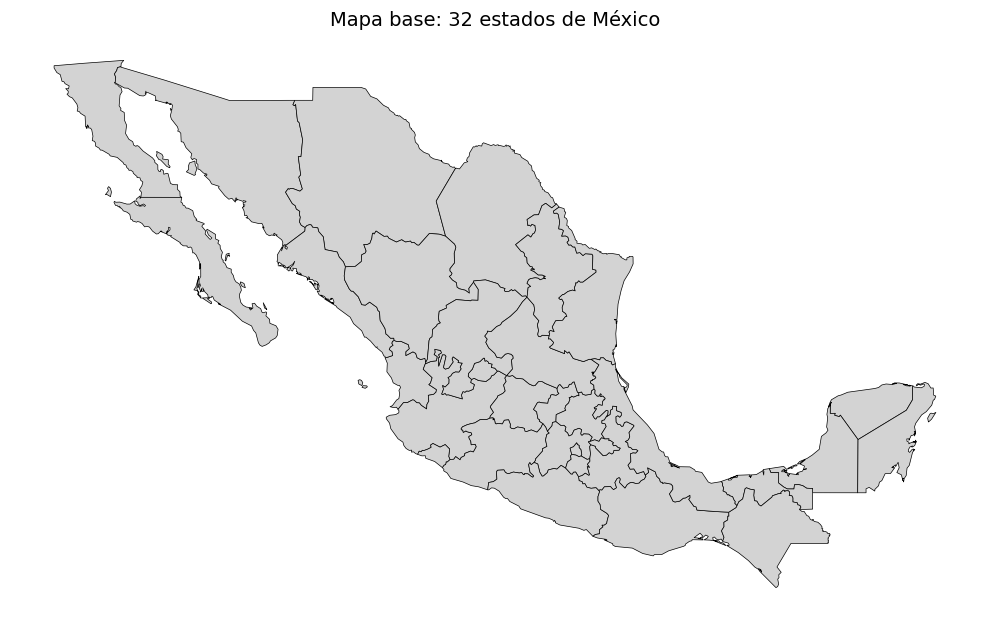

In [5]:
# .plot() dibuja los polígonos del GeoDataFrame.
# Sin especificar una columna de datos, simplemente muestra las formas.
fig, ax = plt.subplots(1, figsize=(10, 7))
mx.plot(
    ax=ax,              # En qué lienzo dibujar
    edgecolor="black",  # Color de las fronteras entre estados
    facecolor="lightgray",  # Color de relleno (gris claro, neutro)
    linewidth=0.5       # Grosor de la línea fronteriza
)
ax.set_title("Mapa base: 32 estados de México", fontsize=14)
ax.set_axis_off()  # Quitamos los ejes x/y porque no aportan en un mapa
plt.tight_layout()
plt.show()

**Observación importante:** Fíjate que los estados del norte de México (Chihuahua, Sonora, Coahuila) son **mucho más grandes en área** que los del centro y sur (Tlaxcala, Morelos, Aguascalientes). Esto es relevante porque nuestro cerebro tiende a prestar más atención a los polígonos grandes, aunque estadísticamente cada estado tiene el mismo peso (una fila = un estado). Esta asimetría visual es una limitación inherente de los mapas coropléticos que debemos tener siempre presente.

### 3.5 Entendiendo la distribución estadística de nuestra variable

Antes de clasificar, SIEMPRE debemos mirar la distribución de los datos. ¿Por qué? Porque la forma de la distribución (simétrica, asimétrica, multimodal, etc.) nos va a indicar qué clasificadores funcionarán bien y cuáles no.

Nuestra variable principal será `PCGDP1940` (PIB per cápita de 1940).

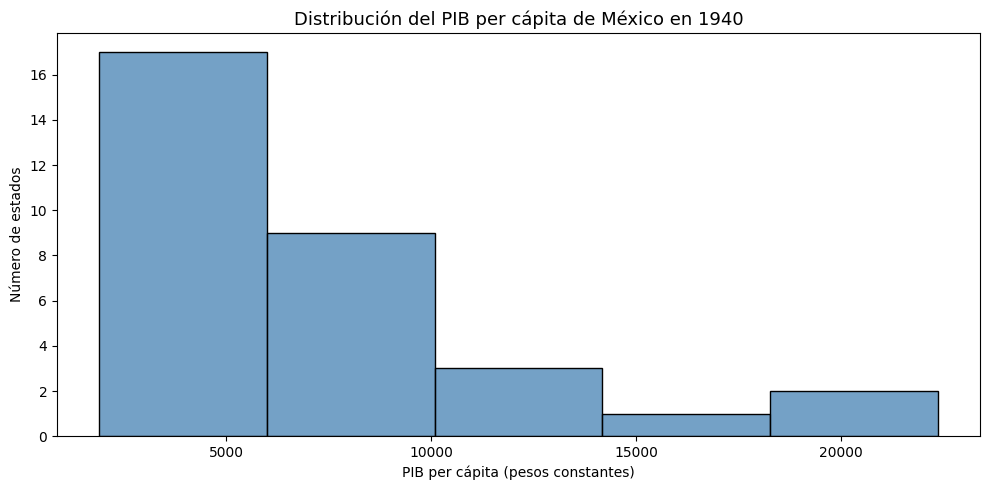

In [9]:
# Creamos un histograma para ver cómo se distribuyen los valores.
#
# ¿Qué es un histograma? Divide el rango de valores en "cajones" (bins)
# y cuenta cuántas observaciones caen en cada cajón. La altura de cada
# barra indica cuántos estados tienen un PIB en ese rango.
#
# El "rug plot" (alfombra) agrega marcas rojas en el eje X: una por cada
# observación individual. Así vemos exactamente dónde está cada estado,
# no solo el conteo agrupado.

fig, ax = plt.subplots(1, figsize=(10, 5))

# Histograma con 5 bins (cajones)
seaborn.histplot(
    mx["PCGDP1940"],  # La columna de datos que queremos graficar
    bins=5,            # Número de cajones
    ax=ax,             # Lienzo donde dibujar
    color="steelblue"  # Color de las barras
)

ax.set_title("Distribución del PIB per cápita de México en 1940", fontsize=13)
ax.set_xlabel("PIB per cápita (pesos constantes)")
ax.set_ylabel("Número de estados")
plt.tight_layout()
plt.show()

**¿Qué vemos?**

- La gran mayoría de los estados (17 de 32) se concentran en el primer cajón, con PIB bajo (menos de ~6,000).
- Unos pocos estados tienen valores mucho más altos, creando una **cola larga a la derecha**.
- Esto se llama una distribución con **asimetría positiva** (right-skewed): muchos valores bajos, pocos valores altos.
- Las rayitas rojas del rug plot muestran que los datos están apretados a la izquierda y esparcidos a la derecha.

Veamos los números exactos con `.describe()`:

In [7]:
estadisticas = mx["PCGDP1940"].describe()
print(estadisticas)
print()
print(f"--- Interpretación ---")
print(f"Hay {int(estadisticas['count'])} estados.")
print(f"El estado más pobre tenía un PIB pc de ${estadisticas['min']:,.0f}")
print(f"El estado más rico tenía un PIB pc de ${estadisticas['max']:,.0f}")
print(f"  -> El más rico era {estadisticas['max']/estadisticas['min']:.1f}x más rico que el más pobre.")
print(f"La media es ${estadisticas['mean']:,.0f} pero la mediana es ${estadisticas['50%']:,.0f}")
print(f"  -> Como la media ({estadisticas['mean']:,.0f}) > mediana ({estadisticas['50%']:,.0f}),")
print(f"     la distribución tiene asimetría positiva.")
print(f"  -> Unos pocos estados muy ricos 'jalan' la media hacia arriba,")
print(f"     pero la mayoría de los estados tiene un PIB cercano a la mediana.")

count       32.000000
mean      7230.531250
std       5204.952883
min       1892.000000
25%       3701.750000
50%       5256.000000
75%       8701.750000
max      22361.000000
Name: PCGDP1940, dtype: float64

--- Interpretación ---
Hay 32 estados.
El estado más pobre tenía un PIB pc de $1,892
El estado más rico tenía un PIB pc de $22,361
  -> El más rico era 11.8x más rico que el más pobre.
La media es $7,231 pero la mediana es $5,256
  -> Como la media (7,231) > mediana (5,256),
     la distribución tiene asimetría positiva.
  -> Unos pocos estados muy ricos 'jalan' la media hacia arriba,
     pero la mayoría de los estados tiene un PIB cercano a la mediana.


### 3.6 El histograma como un problema de clasificación

El histograma que acabamos de hacer ya **ES** una clasificación: dividió los valores en 5 cajones y contó cuántos estados hay en cada uno. Podemos extraer los puntos de corte (*bins*) y los conteos (*counts*) explícitamente.

Internamente, `seaborn` usó la regla de **Freedman-Diaconis** para determinar el ancho de cada cajón.

In [8]:
# Usamos la función hist de matplotlib para obtener los datos numéricos.
# Retorna tres cosas:
#   counts  = cuántas observaciones hay en cada cajón (array de k valores)
#   bins    = los límites de cada cajón (array de k+1 valores, porque
#             k cajones necesitan k+1 fronteras)
#   patches = los objetos gráficos del histograma (rectángulos dibujados;
#             no nos interesan aquí)

fig, ax = plt.subplots(figsize=(8, 4))
counts, bins, patches = ax.hist(mx["PCGDP1940"], bins=5, edgecolor="black")
plt.close()  # Cerramos la figura, solo queríamos los números

print("Conteos por cajón (counts):")
print(f"  {counts}")
print(f"  -> Significado: 17 estados en el 1er cajón, 9 en el 2do, 3 en el 3ro, etc.")
print()
print("Límites de los cajones (bins):")
print(f"  {bins}")
print(f"  -> Son 6 valores porque 5 cajones necesitan 6 fronteras.")
print(f"  -> El primer cajón va de {bins[0]:,.1f} a {bins[1]:,.1f}")
print(f"  -> El segundo cajón va de {bins[1]:,.1f} a {bins[2]:,.1f}")
print()
print(f"Ancho de cada cajón: {bins[1] - bins[0]:,.1f} (son todos iguales)")
print(f"  -> Esto es la regla de 'intervalos iguales': dividir el rango total")
print(f"     ({bins[-1]:,.0f} - {bins[0]:,.0f} = {bins[-1]-bins[0]:,.0f}) entre 5 = {(bins[-1]-bins[0])/5:,.1f}")

Conteos por cajón (counts):
  [17.  9.  3.  1.  2.]
  -> Significado: 17 estados en el 1er cajón, 9 en el 2do, 3 en el 3ro, etc.

Límites de los cajones (bins):
  [ 1892.   5985.8 10079.6 14173.4 18267.2 22361. ]
  -> Son 6 valores porque 5 cajones necesitan 6 fronteras.
  -> El primer cajón va de 1,892.0 a 5,985.8
  -> El segundo cajón va de 5,985.8 a 10,079.6

Ancho de cada cajón: 4,093.8 (son todos iguales)
  -> Esto es la regla de 'intervalos iguales': dividir el rango total
     (22,361 - 1,892 = 20,469) entre 5 = 4,093.8


La regla de **Freedman-Diaconis** calcula el ancho óptimo como:

$$w = 2 \cdot IQR \cdot n^{-1/3}$$

donde:
- $w$ = ancho de cada cajón
- $IQR = Q3 - Q1$ = rango intercuartílico (la diferencia entre el percentil 75 y el 25). Mide la dispersión del 50% central de los datos.
- $n$ = número de observaciones (32 estados)

Y el número de cajones $k$ se obtiene dividiendo el rango total por el ancho:

$$k = \frac{\max - \min}{w}$$

Pero en cartografía temática tenemos muchos más algoritmos, cada uno con sus propias reglas y prioridades. Vamos a explorarlos.

---

## PARTE 4: Algoritmos de clasificación

### El problema formal

Tenemos $n=32$ valores (uno por estado), cada uno con un valor de PIB per cápita. Queremos agruparlos en $k$ clases. El problema es encontrar $k-1$ **puntos de corte** que separen los valores en grupos **mutuamente excluyentes** (un estado solo puede pertenecer a una clase) y **exhaustivos** (todo estado pertenece a alguna clase).

Formalmente, queremos que:

$$c_j < y_i \le c_{j+1} \quad \text{para todo } y_i \text{ en la clase } C_j$$

donde:
- $y_i$ = valor del PIB pc del estado $i$
- $c_j$ = límite inferior de la clase $j$
- $c_{j+1}$ = límite superior de la clase $j$
- $C_j$ = el conjunto de observaciones que pertenecen a la clase $j$

Cada algoritmo define estos límites de manera diferente. Usaremos `mapclassify` para calcularlos.

**Convención:** en todos los ejemplos usaremos $k=5$ clases para poder comparar.

**¿Qué retorna cada clasificador?** Un objeto con varios atributos útiles:
- `.bins` = array con los $k$ puntos de corte (límites superiores de cada clase)
- `.yb` = array de longitud $n$ donde cada posición indica en qué clase (0, 1, ..., $k-1$) quedó cada observación
- `.counts` = array con cuántas observaciones hay en cada clase
- `.adcm` = métrica de ajuste (Absolute Deviation around Class Medians)
- `.name` = nombre del clasificador (string)

### 4.1 Intervalos iguales (*Equal Intervals*)

**La idea más simple:** tomar el rango total de valores y dividirlo en $k$ partes de **igual ancho**.

$$w = \frac{\text{máximo} - \text{mínimo}}{k}$$

En nuestro caso:
$$w = \frac{22{,}361 - 1{,}892}{5} = \frac{20{,}469}{5} = 4{,}093.8$$

Cada cajón tiene exactamente el mismo ancho: 4,093.8 unidades de PIB per cápita.

**Ventaja:** Muy simple de interpretar. Puedes decir "cada clase abarca un rango de \$4,094".

**Desventaja:** Solo mira los extremos (mínimo y máximo). Si la distribución es asimétrica, puede generar clases vacías o muy desequilibradas.

In [11]:
# mapclassify.EqualInterval:
#   Primer argumento: la serie de valores a clasificar (mx["PCGDP1940"])
#   k: número de clases deseadas

ei5 = mapclassify.EqualInterval(mx["PCGDP1940"], k=5)
ei5

EqualInterval

      Interval         Count
----------------------------
[ 1892.00,  5985.80] |    17
( 5985.80, 10079.60] |     9
(10079.60, 14173.40] |     3
(14173.40, 18267.20] |     1
(18267.20, 22361.00] |     2

**Leamos la tabla de salida con detalle:**

| Intervalo | Conteo | ¿Qué significa? |
|:---|:---:|:---|
| [1892.00, 5985.80] | 17 | 17 de 32 estados (53%) tienen PIB pc entre \$1,892 y \$5,986 |
| (5985.80, 10079.60] | 9 | 9 estados (28%) entre \$5,986 y \$10,080 |
| (10079.60, 14173.40] | 3 | Solo 3 estados (9%) en este rango |
| (14173.40, 18267.20] | 1 | Solo 1 estado (3%) |
| (18267.20, 22361.00] | 2 | Solo 2 estados (6%), los más ricos |

**Notación de intervalos:** 
- `[` o `]` = incluido (cerrado). El valor del borde **sí** pertenece a este intervalo.
- `(` o `)` = excluido (abierto). El valor del borde **no** pertenece a este intervalo.
- Ejemplo: `(5985.80, 10079.60]` significa: estrictamente mayor que 5,985.80 Y menor o igual a 10,079.60.

**Problema evidente:** 17 de 32 estados (más de la mitad) caen en la primera clase, y las últimas tres clases juntas solo tienen 6 estados. Si hiciéramos un mapa, el 53% del país sería del mismo color. Perdemos mucha información sobre las diferencias entre los estados más pobres.

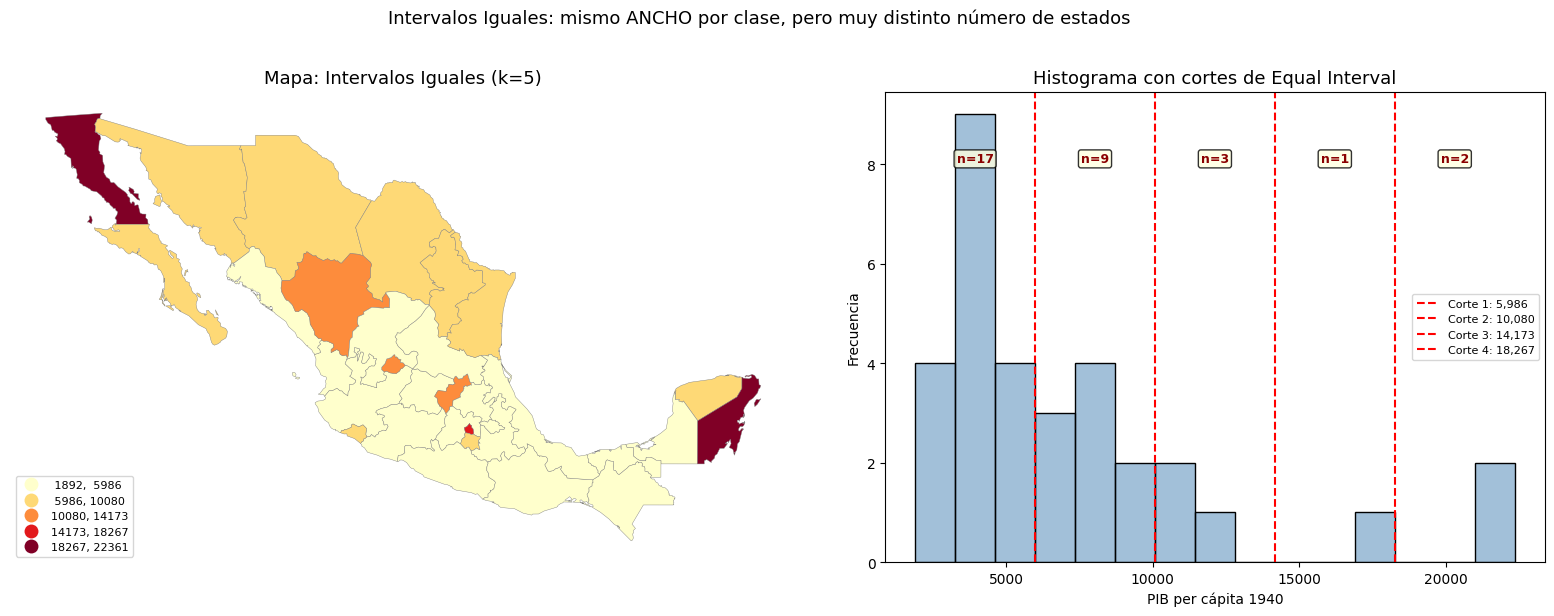

In [14]:
# --- Visualización de Equal Intervals ---
# Dos paneles: mapa (izq) + histograma con cortes (der)

fig, (ax_mapa, ax_hist) = plt.subplots(
    1, 2, figsize=(16, 6),
    gridspec_kw={"width_ratios": [1.3, 1]}
)

# --- MAPA ---
mx.plot(
    column="PCGDP1940",
    scheme="EqualInterval",
    k=5,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"fmt": "{:.0f}", "fontsize": 8, "loc": "lower left"},
    edgecolor="gray", linewidth=0.3,
    ax=ax_mapa
)
ax_mapa.set_axis_off()
ax_mapa.set_title("Mapa: Intervalos Iguales (k=5)", fontsize=13)

# --- HISTOGRAMA con puntos de corte ---
# Histograma fino para ver la distribución real
seaborn.histplot(mx["PCGDP1940"], bins=15, color="steelblue", alpha=0.5, ax=ax_hist)

# Líneas verticales rojas en cada punto de corte de ei5
for i, corte in enumerate(ei5.bins[:-1]):
    ax_hist.axvline(
        x=corte, color="red", linestyle="--", linewidth=1.5,
        label=f"Corte {i+1}: {corte:,.0f}"
    )

# Etiquetas con el conteo de estados en cada clase
limites = numpy.concatenate([[mx['PCGDP1940'].min()], ei5.bins])
for i in range(len(ei5.counts)):
    medio = (limites[i] + limites[i+1]) / 2
    ax_hist.text(
        medio, ax_hist.get_ylim()[1] * 0.85,
        f"n={int(ei5.counts[i])}",
        ha="center", fontsize=9, fontweight="bold", color="darkred",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="lightyellow", alpha=0.8)
    )

ax_hist.set_title("Histograma con cortes de Equal Interval", fontsize=13)
ax_hist.set_xlabel("PIB per cápita 1940")
ax_hist.set_ylabel("Frecuencia")
ax_hist.legend(fontsize=8)

plt.suptitle(
    "Intervalos Iguales: mismo ANCHO por clase, pero muy distinto número de estados",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

### 4.2 Cuantiles (*Quantiles*)

**La idea:** En lugar de que los intervalos tengan el mismo ancho, hacemos que cada clase tenga **aproximadamente el mismo número de observaciones** ($\approx n/k$).

Con $n=32$ estados y $k=5$ clases, cada clase debería tener $\approx 32/5 \approx 6.4$ estados.

Esto se logra usando los **quintiles** (los percentiles 20%, 40%, 60% y 80%) como puntos de corte. El percentil 20% es el valor por debajo del cual cae el 20% de los datos, y así sucesivamente.

**Ventaja:** Evita el problema de clases vacías o muy desequilibradas.

**Desventaja:** Los anchos de los intervalos pueden ser enormemente diferentes, lo que dificulta la interpretación. Además, puede haber problemas con **empates** (muchos valores repetidos).

In [15]:
q5 = mapclassify.Quantiles(mx["PCGDP1940"], k=5)
q5

Quantiles

      Interval         Count
----------------------------
[ 1892.00,  3576.20] |     7
( 3576.20,  4582.80] |     6
( 4582.80,  6925.20] |     6
( 6925.20,  9473.00] |     6
( 9473.00, 22361.00] |     7

Ahora las clases tienen 7, 6, 6, 6, y 7 estados respectivamente. Mucho más equilibrado. Pero miremos los anchos:

In [17]:
# Calculamos la diferencia entre puntos de corte consecutivos
anchos_q = q5.bins[1:] - q5.bins[:-1]
print("Anchos de los intervalos en la clasificación por cuantiles:")
for i, a in enumerate(anchos_q):
    print(f"  Entre clase {i+1} y {i+2}: ancho = {a:,.1f}")
print()
print(f"El intervalo más ancho ({anchos_q.max():,.1f}) es")
print(f"{anchos_q.max()/anchos_q.min():.1f}x más grande que el más angosto ({anchos_q.min():,.1f})")
print()
print("Problema concreto: la última clase va de $9,473 a $22,361.")
print("  -> Un estado con $10,000 y otro con $22,361 quedan en la MISMA clase.")
print("  -> En el mapa se ven del mismo color, pero uno es 2.2x más rico.")
print("  -> La primera clase, en cambio, solo abarca de $1,892 a $3,576 (~$1,684 de rango).")
print("  -> Ahí sí distinguimos bien entre estados pobres, pero no entre los ricos.")

Anchos de los intervalos en la clasificación por cuantiles:
  Entre clase 1 y 2: ancho = 1,006.6
  Entre clase 2 y 3: ancho = 2,342.4
  Entre clase 3 y 4: ancho = 2,547.8
  Entre clase 4 y 5: ancho = 12,888.0

El intervalo más ancho (12,888.0) es
12.8x más grande que el más angosto (1,006.6)

Problema concreto: la última clase va de $9,473 a $22,361.
  -> Un estado con $10,000 y otro con $22,361 quedan en la MISMA clase.
  -> En el mapa se ven del mismo color, pero uno es 2.2x más rico.
  -> La primera clase, en cambio, solo abarca de $1,892 a $3,576 (~$1,684 de rango).
  -> Ahí sí distinguimos bien entre estados pobres, pero no entre los ricos.


#### El problema de los empates (valores repetidos)

Los cuantiles tienen otro problema cuando hay muchos **valores repetidos** (empates). Si el valor mínimo se repite muchas veces, no hay forma de separar esas observaciones en diferentes clases porque son idénticas.

Veamos esto con un ejemplo artificial:

In [18]:
# Creamos una variable artificial para ilustrar el problema
numpy.random.seed(12345)   # Semilla: garantiza que siempre obtenemos los mismos "aleatorios"

# Generamos 20 valores aleatorios entre 0 y 9
x = numpy.random.randint(0, 10, 20)

# Forzamos que los primeros 10 valores sean iguales al mínimo (0)
# Esto simula una variable donde la mitad de las observaciones tiene el mismo valor
x[0:10] = x.min()

print("Valores:", x)
print(f"\nHay {len(x)} valores totales, pero solo {len(numpy.unique(x))} valores únicos:")
print("Valores únicos:", numpy.unique(x))
print(f"\nEl valor 0 se repite {(x == 0).sum()} veces de {len(x)} -> {(x==0).sum()/len(x)*100:.0f}% de los datos")
print("\nSi pedimos 5 clases, necesitamos 4 puntos de corte.")
print("Pero el 55% de los datos tiene el mismo valor (0).")
print("¿Cómo dividimos eso en varias clases? No podemos.")

Valores: [0 0 0 0 0 0 0 0 0 0 9 7 6 0 2 9 1 2 6 7]

Hay 20 valores totales, pero solo 6 valores únicos:
Valores únicos: [0 1 2 6 7 9]

El valor 0 se repite 11 veces de 20 -> 55% de los datos

Si pedimos 5 clases, necesitamos 4 puntos de corte.
Pero el 55% de los datos tiene el mismo valor (0).
¿Cómo dividimos eso en varias clases? No podemos.


In [19]:
# Intentemos clasificar en 5 clases
ties = mapclassify.Quantiles(x, k=5)
ties

/Users/daniela/Documents/usm/cursos/geodata/.venv/lib/python3.11/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


Quantiles

  Interval     Count
--------------------
[0.00, 0.00] |    11
(0.00, 1.40] |     1
(1.40, 6.20] |     4
(6.20, 9.00] |     4

**¿Qué pasó?** Pedimos 5 clases pero obtuvimos solo 4. `mapclassify` detectó que no hay suficientes valores únicos para crear 5 clases bien definidas y automáticamente redujo el número. Usó **pseudo-cuantiles** (cuantiles calculados sobre los valores únicos en lugar de sobre todos los valores) para hacer lo mejor posible.

Esto es importante en la práctica: si tu variable tiene poca variabilidad, muchos ceros, o datos muy concentrados en pocos valores, los cuantiles pueden no funcionar como esperas.

### 4.3 Media y desviación estándar (*Mean-Standard Deviation*)

**La idea:** usar la **media** ($\bar{x}$) como punto de referencia central y la **desviación estándar** ($s$) como "regla" para medir distancias.

Los límites de las 5 clases se definen así:

| Clase | Límite inferior | Límite superior | En palabras |
|:---:|:---:|:---:|:---|
| 0 | $-\infty$ | $\bar{x} - 2s$ | Más de 2 desviaciones estándar **debajo** de la media |
| 1 | $\bar{x} - 2s$ | $\bar{x} - s$ | Entre 1 y 2 desviaciones debajo |
| 2 | $\bar{x} - s$ | $\bar{x} + s$ | Dentro de 1 desviación de la media ("alrededor del promedio") |
| 3 | $\bar{x} + s$ | $\bar{x} + 2s$ | Entre 1 y 2 desviaciones arriba |
| 4 | $\bar{x} + 2s$ | $+\infty$ | Más de 2 desviaciones estándar **arriba** de la media |

**¿Cuándo funciona bien?** Cuando los datos siguen una distribución **normal** (campana de Gauss), simétrica alrededor de la media. En una normal, ~68% cae dentro de ±1s y ~95% dentro de ±2s, así que cada clase tiene una cantidad razonable.

**¿Qué pasa con datos asimétricos?** Veamos:

In [20]:
msd = mapclassify.StdMean(mx["PCGDP1940"])
msd

StdMean

      Interval         Count
----------------------------
(    -inf, -3179.37] |     0
(-3179.37,  2025.58] |     1
( 2025.58, 12435.48] |    28
(12435.48, 17640.44] |     0
(17640.44, 22361.00] |     3

In [21]:
# Calculamos los límites manualmente para entender qué pasó
media = mx["PCGDP1940"].mean()
desv = mx["PCGDP1940"].std()

print(f"Media (x̄)                   = {media:>10,.2f}")
print(f"Desviación estándar (s)      = {desv:>10,.2f}")
print()
print(f"Límite clase 0: x̄ - 2s      = {media - 2*desv:>10,.2f}")
print(f"  -> ¡Es NEGATIVO! Imposible para PIB per cápita.")
print(f"  -> Resultado: la clase 0 tiene 0 observaciones. Clase vacía.")
print()
print(f"Límite clase 1: x̄ - s       = {media - desv:>10,.2f}")
print(f"  -> Solo 1 estado cae entre {media - 2*desv:,.0f} y {media - desv:,.0f}")
print()
print(f"Límite clase 2: x̄ + s       = {media + desv:>10,.2f}")
print(f"  -> 28 de 32 estados quedan entre {media - desv:,.0f} y {media + desv:,.0f}")
print(f"  -> ¡El 87.5% de los datos en UNA sola clase!")
print(f"  -> Un mapa con esto sería casi monocolor. Inútil.")

Media (x̄)                   =   7,230.53
Desviación estándar (s)      =   5,204.95

Límite clase 0: x̄ - 2s      =  -3,179.37
  -> ¡Es NEGATIVO! Imposible para PIB per cápita.
  -> Resultado: la clase 0 tiene 0 observaciones. Clase vacía.

Límite clase 1: x̄ - s       =   2,025.58
  -> Solo 1 estado cae entre -3,179 y 2,026

Límite clase 2: x̄ + s       =  12,435.48
  -> 28 de 32 estados quedan entre 2,026 y 12,435
  -> ¡El 87.5% de los datos en UNA sola clase!
  -> Un mapa con esto sería casi monocolor. Inútil.


**Conclusión:** Para datos con **asimetría positiva** (como los nuestros), este clasificador es una pésima elección. Concentra casi todo en la clase central y desperdicia las demás clases. Solo úsalo cuando tus datos sean aproximadamente simétricos.

### 4.4 Cortes máximos (*Maximum Breaks*)

**La idea central:** buscar los "huecos" más grandes entre valores vecinos y cortar ahí.

#### Ejemplo con datos inventados

Supongamos que tenemos **10 pueblos** con estos ingresos mensuales (ya ordenados de menor a mayor):

$$\$2, \quad \$3, \quad \$4, \quad \$5, \quad \$12, \quad \$13, \quad \$14, \quad \$30, \quad \$31, \quad \$32$$

Queremos formar **3 grupos** ($k=3$), lo que significa que necesitamos **2 puntos de corte**.

**Paso 1 — Calcular las diferencias entre cada par de vecinos:**

| De → a | Diferencia |
|:---|---:|
| \$2 → \$3 | \$1 |
| \$3 → \$4 | \$1 |
| \$4 → \$5 | \$1 |
| **\$5 → \$12** | **\$7** ← segundo salto más grande |
| \$12 → \$13 | \$1 |
| \$13 → \$14 | \$1 |
| **\$14 → \$30** | **\$16** ← ¡el salto más grande! |
| \$30 → \$31 | \$1 |
| \$31 → \$32 | \$1 |

**Paso 2 — Elegir las $k-1 = 2$ diferencias más grandes:**

1. La mayor: **\$16** (entre \$14 y \$30)
2. La segunda mayor: **\$7** (entre \$5 y \$12)

**Paso 3 — Cortar ahí. Resultado:**

| Grupo | Pueblos | Interpretación |
|:---:|:---|:---|
| 1 | \$2, \$3, \$4, \$5 | Pueblos pobres |
| | ↕ *salto de \$7* | |
| 2 | \$12, \$13, \$14 | Pueblos medios |
| | ↕ *salto de \$16* | |
| 3 | \$30, \$31, \$32 | Pueblos ricos |

La lógica es intuitiva: si entre dos valores consecutivos hay un hueco enorme, probablemente pertenecen a **grupos naturales distintos**. El algoritmo simplemente encuentra esos huecos y pone los cortes ahí.

In [43]:
mb5 = mapclassify.MaximumBreaks(mx["PCGDP1940"], k=5)
mb5

MaximumBreaks

      Interval         Count
----------------------------
[ 1892.00,  5854.00] |    17
( 5854.00, 11574.00] |    11
(11574.00, 14974.00] |     1
(14974.00, 19890.50] |     1
(19890.50, 22361.00] |     2

La distribución del PIB de México es asimétrica con la mayoría de estados concentrados en valores bajos, sin grupos naturales bien separados. El resultado lo confirma: 17 estados en una clase y dos clases con un solo estado cada una. El mapa tendría el 53% del país de un mismo color y dos estados pintados como si fueran "categorías" propias, lo cual no aporta mucho.

### 4.5 Diagrama de caja (*Box Plot*)

Este clasificador usa las zonas del **diagrama de caja y bigotes** como clases. Para entenderlo, necesitamos 4 números:

- **Q1** (percentil 25): el 25% de los datos está por debajo.
- **Q3** (percentil 75): el 75% está por debajo.
- **IQR** = Q3 - Q1: la "anchura" del 50% central de los datos.
- **h** (bisagra, por defecto 1.5): un multiplicador que define qué tan lejos del centro es "atípico".

Con estos se calculan los **límites de los bigotes**:

$$\text{Bigote inferior} = Q1 - h \times IQR$$
$$\text{Bigote superior} = Q3 + h \times IQR$$

Todo lo que caiga fuera de los bigotes es un **outlier** (valor atípico). Esto genera exactamente **6 clases fijas**:

In [23]:
bp = mapclassify.BoxPlot(mx["PCGDP1940"])  # h=1.5 por defecto
bp

BoxPlot

      Interval         Count
----------------------------
(    -inf, -3798.25] |     0
(-3798.25,  3701.75] |     8
( 3701.75,  5256.00] |     8
( 5256.00,  8701.75] |     8
( 8701.75, 16201.75] |     5
(16201.75, 22361.00] |     3

### 4.6 Head-Tail Breaks

**La idea (Jiang, 2013):** Un algoritmo **recursivo** diseñado para distribuciones con **colas pesadas** (donde la mayoría de los datos son pequeños pero unos pocos son enormes).

Funciona así, paso a paso:
1. Calcula la **media** de todos los datos. Este es el primer punto de corte.
2. Los datos se dividen en dos: los que están **por debajo** de la media (la "cola", tail) y los que están **por arriba** (la "cabeza", head).
3. Toma **solo los de arriba** y repite: calcula su media, divide otra vez...
4. Se detiene cuando la proporción de datos en la "cabeza" supera el 40% (ya no hay cola pesada).

**Nota importante:** A diferencia de los demás clasificadores, no puedes elegir $k$ a priori. El algoritmo decide cuántas clases crear según la estructura de los datos.

In [25]:
ht = mapclassify.HeadTailBreaks(mx["PCGDP1940"])
ht

HeadTailBreaks

      Interval         Count
----------------------------
[ 1892.00,  7230.53] |    20
( 7230.53, 12244.42] |     9
(12244.42, 20714.00] |     1
(20714.00, 22163.00] |     1
(22163.00, 22361.00] |     1

In [26]:
# Entendamos la recursión:
print("Iteración 1:")
print(f"  Media de los 32 valores = {mx['PCGDP1940'].mean():,.2f}")
print(f"  -> Primer punto de corte: {ht.bins[0]:,.2f}")
print(f"  -> {(mx['PCGDP1940'] <= ht.bins[0]).sum()} estados debajo (cola) | "
      f"{(mx['PCGDP1940'] > ht.bins[0]).sum()} arriba (cabeza)")

# Ahora toma solo los 12 de arriba y repite
arriba1 = mx.loc[mx['PCGDP1940'] > ht.bins[0], 'PCGDP1940']
print(f"\nIteración 2 (solo con los {len(arriba1)} de arriba):")
print(f"  Media de estos = {arriba1.mean():,.2f}")
print(f"  -> Segundo punto de corte: {ht.bins[1]:,.2f}")
print(f"  -> {(arriba1 <= ht.bins[1]).sum()} abajo | {(arriba1 > ht.bins[1]).sum()} arriba")
print("  -> Y así sigue recursivamente...")

Iteración 1:
  Media de los 32 valores = 7,230.53
  -> Primer punto de corte: 7,230.53
  -> 20 estados debajo (cola) | 12 arriba (cabeza)

Iteración 2 (solo con los 12 de arriba):
  Media de estos = 12,244.42
  -> Segundo punto de corte: 12,244.42
  -> 9 abajo | 3 arriba
  -> Y así sigue recursivamente...


### 4.7 Jenks-Caspall

**La idea (Jenks y Caspall, 1971):** Un algoritmo **heurístico** que busca minimizar la **suma de desviaciones absolutas alrededor de las medias de cada clase**. Es el caso unidimensional del famoso algoritmo **K-Means** que veremos más adelante en el curso (en el tema de Clustering).

**Paso a paso:**
1. Comienza con una partición inicial arbitraria (por ejemplo, cuantiles).
2. Para cada clase, calcula su media.
3. Considera mover el valor más alto de una clase a la clase de arriba, y el valor más bajo de una clase a la clase de abajo.
4. Si alguno de esos movimientos reduce la suma total de desviaciones, lo ejecuta.
5. Repite hasta que ningún movimiento posible mejore el resultado.

**Es heurístico:** puede quedar atrapado en un **mínimo local** (una solución "buena" pero no la mejor posible).

In [27]:
numpy.random.seed(12345)  # Semilla para reproducibilidad (el resultado depende de la inicialización)
jc5 = mapclassify.JenksCaspall(mx["PCGDP1940"], k=5)
jc5

JenksCaspall

      Interval         Count
----------------------------
[ 1892.00,  2934.00] |     4
( 2934.00,  4414.00] |     9
( 4414.00,  6399.00] |     5
( 6399.00, 12132.00] |    11
(12132.00, 22361.00] |     3

### 4.8 Fisher-Jenks

**La idea:** Igual que Jenks-Caspall (minimizar desviaciones dentro de cada clase), pero usa **programación dinámica** en lugar de una heurística. Esto **garantiza** encontrar la clasificación óptima para un $k$ dado.

**¿Entonces por qué no usamos siempre Fisher-Jenks?** Porque es más costoso computacionalmente. Con 32 observaciones no importa, pero con millones de puntos puede ser muy lento. Además, el óptimo estadístico no siempre produce el mejor mapa — a veces queremos un criterio diferente.

In [28]:
numpy.random.seed(12345)
fj5 = mapclassify.FisherJenks(mx["PCGDP1940"], k=5)
fj5

FisherJenks

      Interval         Count
----------------------------
[ 1892.00,  5309.00] |    17
( 5309.00,  9073.00] |     8
( 9073.00, 12132.00] |     4
(12132.00, 17816.00] |     1
(17816.00, 22361.00] |     2

### 4.9 Max-P

**La idea (Duque, Anselin y Rey, 2011):** Aplica el método *max-p* de construcción de regiones al problema de clasificación. Similar a Jenks-Caspall (intercambios heurísticos entre clases adyacentes), pero con una formulación diferente del problema de optimización. **No garantiza optimalidad.**

In [29]:
mp5 = mapclassify.MaxP(mx["PCGDP1940"], k=5)
mp5

MaxP

      Interval         Count
----------------------------
[ 1892.00,  3569.00] |     7
( 3569.00,  5309.00] |    10
( 5309.00,  7990.00] |     5
( 7990.00,  9573.00] |     4
( 9573.00, 22361.00] |     6

---

## PARTE 5: Comparación de clasificadores

Hemos visto 8 clasificadores aplicados a los mismos datos. Cada uno produce clases diferentes. ¿Cuál es "mejor"?

### 5.1 Métrica ADCM (Absolute Deviation around Class Medians)

La ADCM mide qué tan **compacta** (homogénea) es cada clase. Se calcula así:
1. Para cada clase, encuentra la **mediana** de los valores que contiene.
2. Calcula la desviación absoluta de cada valor respecto a la mediana de su clase: $|y_i - \text{mediana}(C_j)|$
3. Suma todas esas desviaciones.

Un ADCM **más bajo** = las clases son internamente más homogéneas = mejor ajuste estadístico.

In [30]:
# Agrupamos todos los clasificadores en una tupla para procesarlos juntos
class5 = (q5, ei5, ht, mb5, msd, fj5, jc5, mp5)

# Extraemos el ADCM de cada uno
print("ADCM por clasificador (menor = mejor ajuste):")
print("=" * 50)
for c in sorted(class5, key=lambda x: x.adcm):
    print(f"  {c.name:25s}  ADCM = {c.adcm:>10,.0f}")
print("=" * 50)

ADCM por clasificador (menor = mejor ajuste):
  FisherJenks                ADCM =     23,729
  EqualInterval              ADCM =     23,869
  JenksCaspall               ADCM =     25,189
  MaximumBreaks              ADCM =     26,994
  HeadTailBreaks             ADCM =     33,202
  MaxP                       ADCM =     40,877
  Quantiles                  ADCM =     44,481
  StdMean                    ADCM =     68,296


/var/folders/4m/3wpqgpmj1mj_hgdh7mk_1g380000gn/T/ipykernel_28227/3431162099.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  seaborn.barplot(


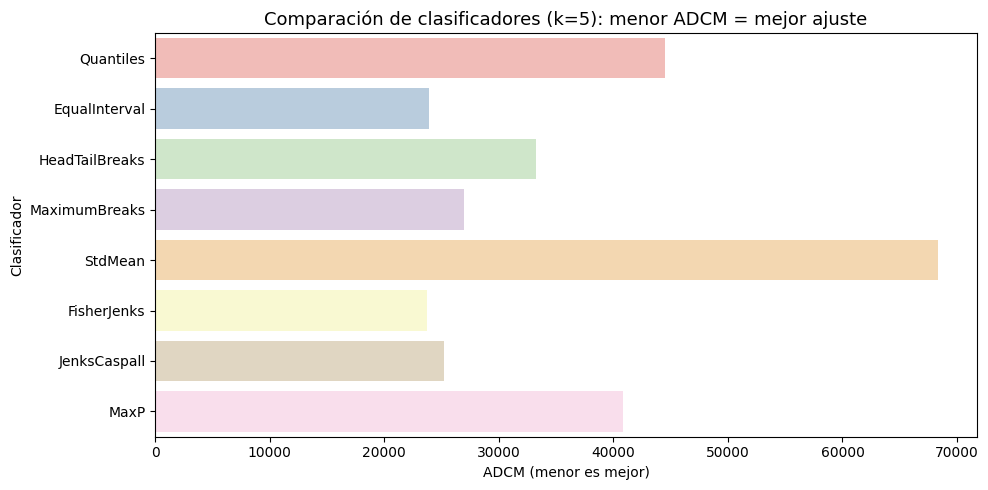

In [31]:
# Visualicemos en un gráfico de barras
adcms = pandas.DataFrame({
    "ADCM": [c.adcm for c in class5],
    "Clasificador": [c.name for c in class5]
})

fig, ax = plt.subplots(1, figsize=(10, 5))
seaborn.barplot(
    y="Clasificador",    # Eje vertical: nombre del clasificador
    x="ADCM",            # Eje horizontal: valor del ADCM
    data=adcms,          # DataFrame con los datos
    palette="Pastel1",   # Paleta de colores para las barras
    ax=ax
)
ax.set_title("Comparación de clasificadores (k=5): menor ADCM = mejor ajuste", fontsize=13)
ax.set_xlabel("ADCM (menor es mejor)")
plt.tight_layout()
plt.show()

**Interpretación detallada:**

- **Fisher-Jenks** tiene el ADCM más bajo. Esto no sorprende: es el único que **garantiza** la solución óptima mediante programación dinámica.
- **StdMean** (media-desviación estándar) tiene el peor ajuste, con diferencia. Esto ocurre porque mete 28 de 32 estados en una sola clase enorme, cuya mediana queda lejos de muchos de sus miembros.
- **EqualInterval** funciona sorprendentemente bien a pesar de ser el más simple. Esto es un recordatorio de que simple no significa malo.

**Advertencia:** Un buen ADCM no garantiza un buen mapa. La ADCM mide ajuste **estadístico** (homogeneidad interna de clases), pero un buen mapa también necesita comunicar eficazmente los **patrones espaciales**. A veces, un clasificador con peor ADCM produce un mapa más informativo según el contexto.

### 5.2 Mapa de calor: ¿cómo clasifica cada algoritmo a cada estado?

Para ver las diferencias a nivel de observaciones individuales, añadimos la clase asignada por cada algoritmo al GeoDataFrame. El atributo `.yb` ("y binned") es un array donde cada posición indica en qué clase (0, 1, ..., k-1) quedó cada observación.

In [32]:
# .yb retorna un array de 32 valores (uno por estado).
# Ejemplo: si yb[0] = 3, significa que el primer estado (Baja California Norte)
# fue asignado a la clase 3 por ese clasificador.

mx["Cuantiles"] = q5.yb
mx["Intervalos Iguales"] = ei5.yb
mx["Head-Tail Breaks"] = ht.yb
mx["Cortes Máximos"] = mb5.yb
mx["Media-Desv. Est."] = msd.yb
mx["Fisher-Jenks"] = fj5.yb
mx["Jenks Caspall"] = jc5.yb
mx["MaxP"] = mp5.yb

# Veamos cómo fue clasificado cada estado por tres algoritmos distintos
# Ordenamos por PIB para ver si las asignaciones son consistentes
print("Ejemplo: los 8 estados más pobres y sus clases asignadas")
mx[["NAME", "PCGDP1940", "Cuantiles", "Fisher-Jenks", "Intervalos Iguales"]].sort_values("PCGDP1940").head(8)

Ejemplo: los 8 estados más pobres y sus clases asignadas


,NAME,PCGDP1940,Cuantiles,Fisher-Jenks,Intervalos Iguales
19,Oaxaca,1892.0,0,0,0
18,Guerrero,2181.0,0,0,0
20,Tabasco,2459.0,0,0,0
21,Chiapas,2934.0,0,0,0
8,Michoacan de Ocampo,3327.0,0,0,0
9,Mexico,3408.0,0,0,0
15,Puebla,3569.0,0,0,0
17,Tlaxcala,3605.0,1,0,0


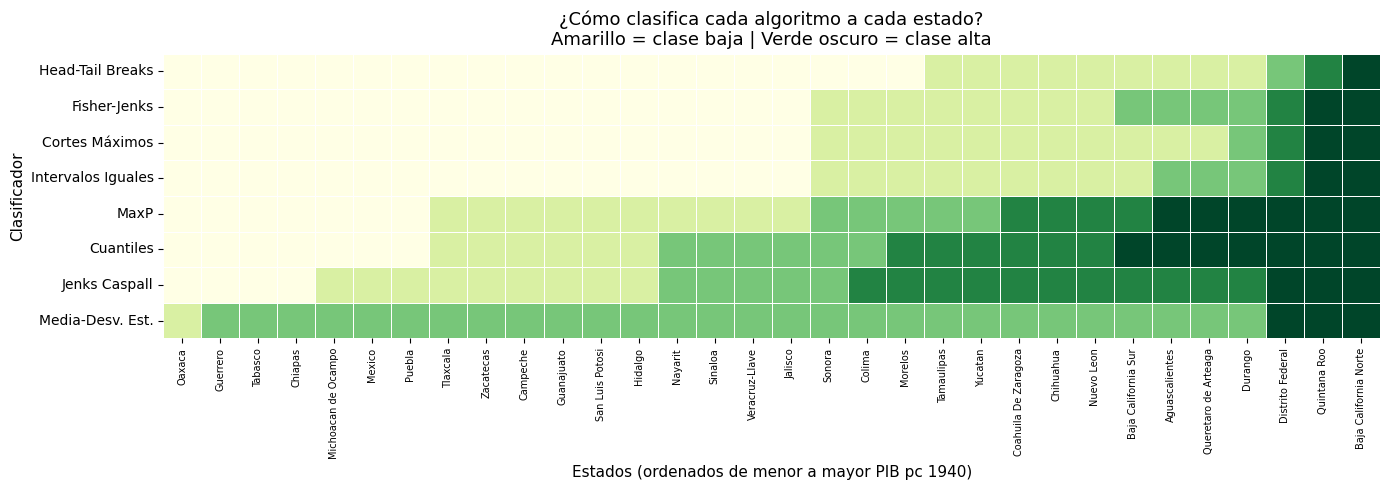

In [33]:
# Mapa de calor (heatmap) comparativo.
#
# ¿Cómo se lee?
#   - Cada FILA = un clasificador
#   - Cada COLUMNA = un estado (ordenados de izq. a der. de menor a mayor PIB)
#   - El COLOR = la clase asignada (amarillo claro = clase más baja,
#                                    verde oscuro = clase más alta)
#
# Operaciones encadenadas:
#   .set_index("NAME")       -> usamos el nombre del estado como índice de fila
#   .sort_values("PCGDP1940") -> ordenamos las filas por PIB (pobre -> rico)
#   [cols_clasif]            -> seleccionamos solo las columnas de clasificación
#   .T                       -> transponemos la tabla (filas <-> columnas)
#                               para que los estados queden en el eje horizontal

cols_clasif = [
    "Head-Tail Breaks", "Fisher-Jenks", "Cortes Máximos",
    "Intervalos Iguales", "MaxP", "Cuantiles",
    "Jenks Caspall", "Media-Desv. Est."
]

datos_heatmap = (
    mx.set_index("NAME")
      .sort_values("PCGDP1940")
      [cols_clasif]
      .T
)

f, ax = plt.subplots(1, figsize=(14, 5))
seaborn.heatmap(
    datos_heatmap,
    cmap="YlGn",         # Paleta amarillo -> verde
    cbar=False,           # Sin barra de colores lateral
    ax=ax,
    linewidths=0.5,       # Líneas blancas entre celdas
    linecolor="white"
)
ax.set_xlabel("Estados (ordenados de menor a mayor PIB pc 1940)", fontsize=11)
ax.set_ylabel("Clasificador", fontsize=11)
ax.set_title(
    "¿Cómo clasifica cada algoritmo a cada estado?\n"
    "Amarillo = clase baja | Verde oscuro = clase alta",
    fontsize=13
)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

**¿Qué revelaciones nos da este gráfico?**

- **Baja California Norte** (extremo derecho, el más rico) es el **único estado** que todos los clasificadores asignan consistentemente a la clase más alta. Es tan claramente el más rico que no importa qué método uses.

- **Media-Desv. Est.** (última fila) es casi toda del mismo color verde medio → el 87.5% de los estados cae en la clase 2 (central). Un mapa con esto sería prácticamente monocolor e inútil para distinguir patrones.

- **Cuantiles** muestra una transición gradual y uniforme de amarillo a verde → las clases están equilibradas. Cada "franja" de color tiene más o menos el mismo ancho.

- Los estados del **centro** de la distribución (ni los más pobres ni los más ricos) son donde más **desacuerdo** hay entre clasificadores. Los extremos tienden a ser clasificados consistentemente.

### 5.3 Tabla de conteos por clase

In [34]:
# c.counts retorna un array con cuántos estados hay en cada clase (0, 1, ..., 4)
conteos = pandas.DataFrame(
    {c.name: c.counts for c in class5},
    index=[f"Clase {i}" for i in range(5)],
)
conteos

,Quantiles,EqualInterval,HeadTailBreaks,MaximumBreaks,StdMean,FisherJenks,JenksCaspall,MaxP
Clase 0,7,17,20,17,0,17,4,7
Clase 1,6,9,9,11,1,8,9,10
Clase 2,6,3,1,1,28,4,5,5
Clase 3,6,1,1,1,0,1,11,4
Clase 4,7,2,1,2,3,2,3,6


---

## PARTE 6: El color — Cómo NO mentir con un mapa

Elegir colores no es solo estética. Una mala elección de color puede comunicar información **falsa**. La regla fundamental es: **la paleta debe corresponder al tipo de variable.**

### Nota previa: el sesgo de área

Antes de ver paletas, recordemos algo: los estados de México tienen áreas muy diferentes. Chihuahua es ~115 veces más grande que Tlaxcala. Nuestro cerebro presta más atención a los polígonos grandes, pero estadísticamente cada estado pesa lo mismo. Tenlo siempre presente al interpretar mapas coropléticos.

### Mecánica: cómo hacer un mapa coroplético con geopandas

Usamos `.plot()` del GeoDataFrame, indicando qué columna queremos representar con color.

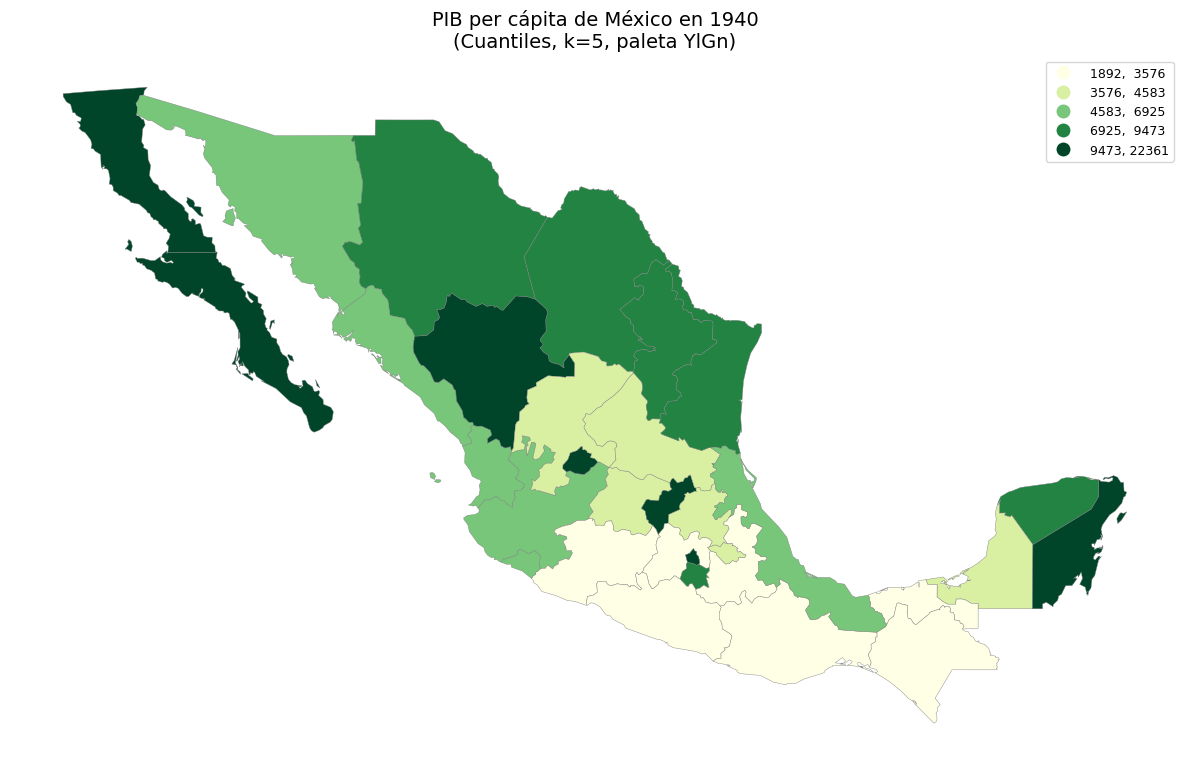

In [35]:
# Mapa coroplético completo con explicación de cada parámetro:

fig, ax = plt.subplots(1, figsize=(12, 8))

mx.plot(
    column="PCGDP1940",    # ¿Qué columna queremos representar con color?
    scheme="Quantiles",     # ¿Qué algoritmo de clasificación? (internamente usa mapclassify)
    k=5,                    # ¿Cuántas clases?
    cmap="YlGn",            # ¿Qué paleta de color? YlGn = amarillo a verde (secuencial)
    legend=True,            # ¿Mostrar leyenda? Sí
    legend_kwds={           # Formato de la leyenda:
        "fmt": "{:.0f}",    #   Sin decimales para legibilidad
        "fontsize": 9
    },
    edgecolor="gray",       # Color de las fronteras entre estados
    linewidth=0.3,          # Grosor de las fronteras
    ax=ax
)

ax.set_axis_off()
ax.set_title("PIB per cápita de México en 1940\n(Cuantiles, k=5, paleta YlGn)", fontsize=14)
plt.tight_layout()
plt.show()

### 6.1 Paletas secuenciales

**¿Cuándo usarlas?** Cuando la variable tiene un **orden natural de bajo a alto** y no hay un punto medio especial. Ejemplos: ingresos, población, temperatura absoluta, altitud, densidad.

**Características:** Van de un color claro (valores bajos) a un color oscuro (valores altos). Pueden usar un solo tono (ej: `Blues` = azul claro a oscuro) o dos tonos (ej: `YlGn` = amarillo a verde).

**Ejemplos populares:** `Blues`, `Greens`, `Reds`, `Oranges`, `YlGn`, `YlOrRd`, `viridis`.

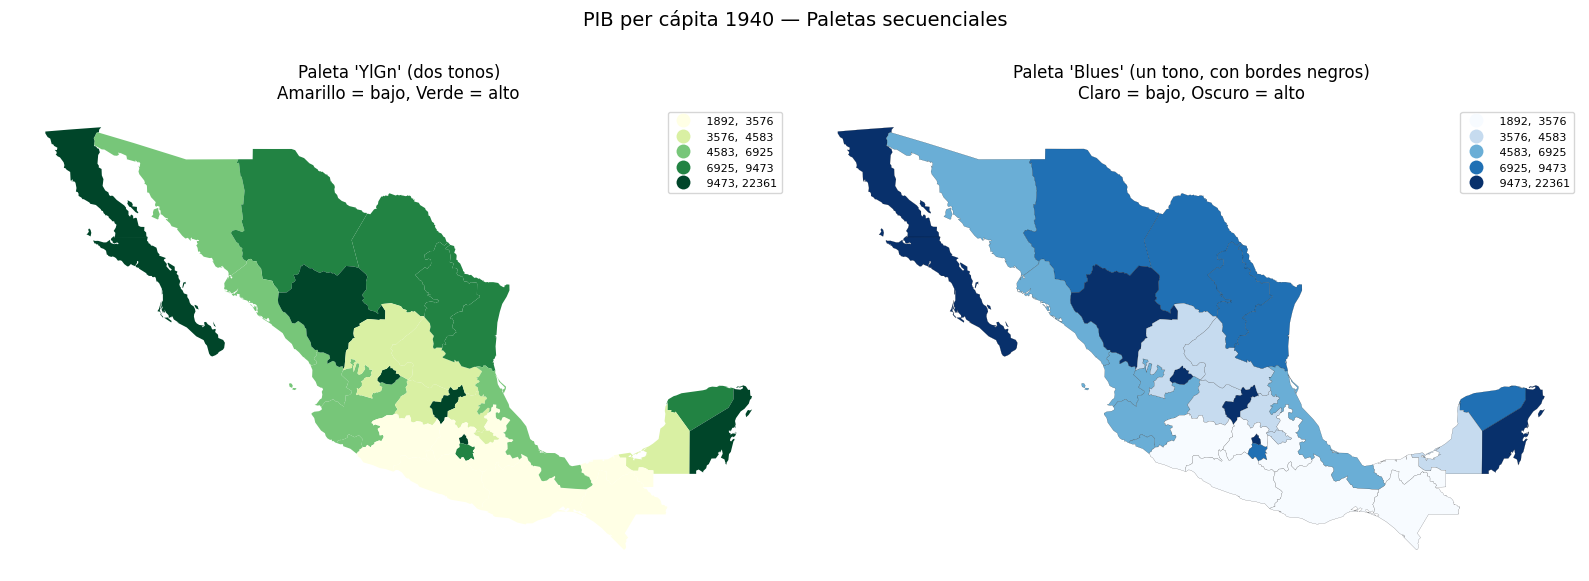

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Paleta YlGn (Amarillo -> Verde): dos tonos
mx.plot(
    column="PCGDP1940", scheme="Quantiles", cmap="YlGn",
    legend=True, legend_kwds={"fmt": "{:.0f}", "fontsize": 8},
    ax=axes[0]
)
axes[0].set_axis_off()
axes[0].set_title("Paleta 'YlGn' (dos tonos)\nAmarillo = bajo, Verde = alto", fontsize=12)

# Paleta Blues (tonos de azul): un solo tono
# Necesitamos bordes negros porque los valores bajos se pintan casi blanco
mx.plot(
    column="PCGDP1940", scheme="Quantiles", cmap="Blues",
    edgecolor="black", linewidth=0.1,
    legend=True, legend_kwds={"fmt": "{:.0f}", "fontsize": 8},
    ax=axes[1]
)
axes[1].set_axis_off()
axes[1].set_title("Paleta 'Blues' (un tono, con bordes negros)\nClaro = bajo, Oscuro = alto", fontsize=12)

plt.suptitle("PIB per cápita 1940 — Paletas secuenciales", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**¿Por qué bordes negros en 'Blues'?** Sin ellos, los estados con valores bajos se pintan de azul casi blanco, confundiéndose con el fondo. Los bordes negros permiten ver la frontera de cada estado aunque el relleno sea muy claro.

### 6.2 Paletas divergentes

**¿Cuándo usarlas?** Cuando la variable tiene un **punto medio significativo** y nos interesa enfatizar las desviaciones en **ambas direcciones**.

**Ejemplos de variables divergentes:** cambio porcentual (puede ser + o -), anomalía de temperatura respecto a la media, diferencia de votos entre dos partidos, cambio en ranking.

**Características:** Colores claros en el centro (valor neutro/cero), colores oscuros con **matices contrastantes** en los extremos (ej: rojo para negativo, verde para positivo).

Vamos a crear una variable divergente: el **cambio en el ranking** de ingresos entre 1940 y 2000.

In [37]:
# Paso 1: Crear un ranking de ingresos.
# .rank(ascending=False) asigna:
#   - Rango 1 al estado con MAYOR PIB (el más rico)
#   - Rango 32 al estado con MENOR PIB (el más pobre)

rnk = mx[["NAME", "PCGDP1940", "PCGDP2000"]].rank(ascending=False)

# Paso 2: Calcular el CAMBIO de rango entre 1940 y 2000.
# Ejemplo 1: Estado con rango 10 en 1940 y rango 5 en 2000:
#   cambio = 10 - 5 = +5 -> MEJORÓ 5 posiciones (subió en el ranking de riqueza)
# Ejemplo 2: Estado con rango 5 en 1940 y rango 15 en 2000:
#   cambio = 5 - 15 = -10 -> EMPEORÓ 10 posiciones (bajó en el ranking)
# Ejemplo 3: cambio = 0 -> Se mantuvo igual

rnk["cambio"] = rnk["PCGDP1940"] - rnk["PCGDP2000"]

# Paso 3: Crear categorías con pandas.cut()
# pandas.cut(datos, bordes) asigna cada valor a una categoría según los bordes:
#   (-inf, -5]  -> bajó más de 5 posiciones (fuerte descenso)
#   (-5,   0]   -> bajó entre 0 y 5 posiciones (leve descenso)
#   (0,    5]   -> subió entre 0 y 5 posiciones (leve ascenso)
#   (5,   20]   -> subió más de 5 posiciones (fuerte ascenso)

rnk["clase"] = pandas.cut(
    rnk["cambio"],
    [-numpy.inf, -5, 0, 5, 20]  # Los 5 bordes definen 4 categorías
)

print("Distribución de cambios:")
print(rnk["clase"].value_counts().sort_index())

Distribución de cambios:
clase
(-inf, -5.0]     6
(-5.0, 0.0]     11
(0.0, 5.0]      10
(5.0, 20.0]      5
Name: count, dtype: int64


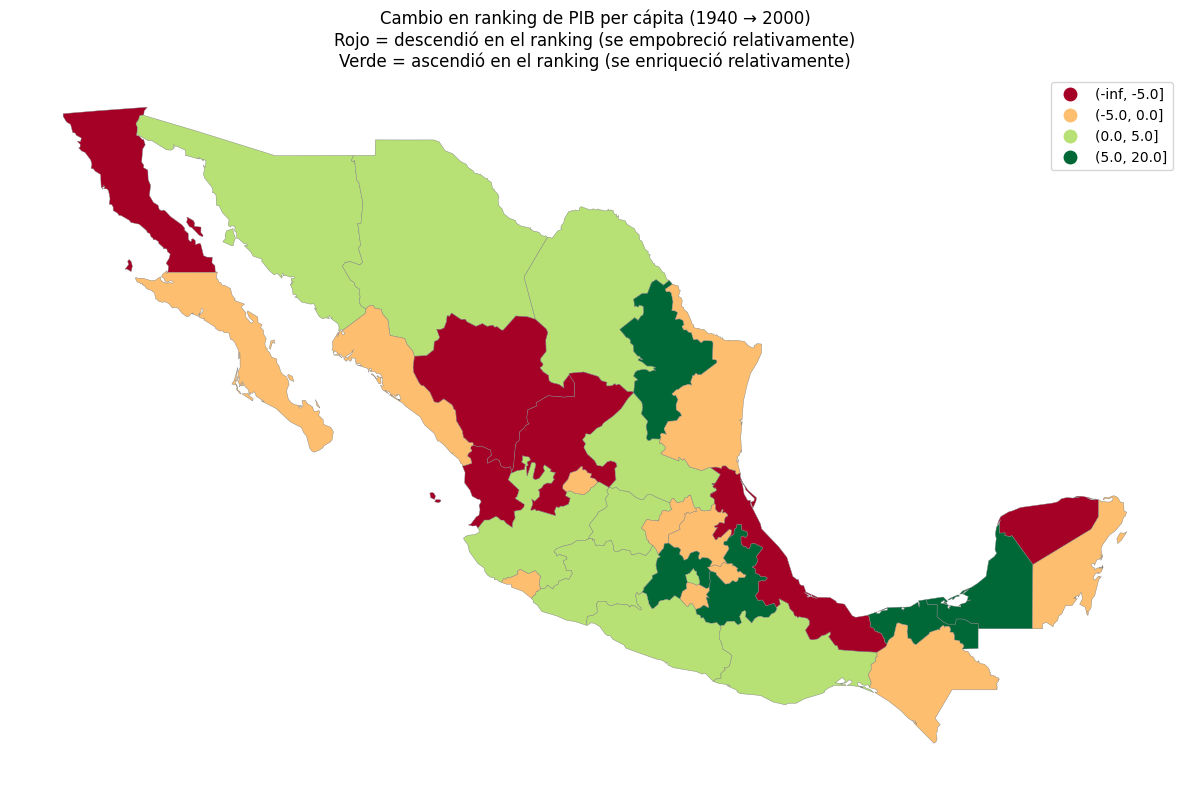

In [38]:
# Mapa divergente
fig, ax = plt.subplots(1, figsize=(12, 8))

# mx[["geometry"]] -> tomamos SOLO la columna de geometría del GeoDataFrame original
# .join(rnk)       -> le pegamos las columnas de ranking calculadas arriba
# .plot("clase")   -> coloreamos según la categoría de cambio

(
    mx[["geometry"]]
    .join(rnk)
    .plot(
        "clase",
        legend=True,
        cmap="RdYlGn",    # Rojo -> Amarillo -> Verde
        edgecolor="gray", linewidth=0.3,
        ax=ax
    )
)
ax.set_axis_off()
ax.set_title(
    "Cambio en ranking de PIB per cápita (1940 → 2000)\n"
    "Rojo = descendió en el ranking (se empobreció relativamente)\n"
    "Verde = ascendió en el ranking (se enriqueció relativamente)",
    fontsize=12
)
plt.tight_layout()
plt.show()

### 6.3 Paletas cualitativas

**¿Cuándo usarlas?** Cuando la variable es **categórica** (nominal): indica **pertenencia a un grupo**, no una cantidad. Los colores NO deben implicar orden ni gradiente, solo diferencia.

**Error gravísimo:** Usar una paleta secuencial para una variable categórica. Esto hace que el lector piense que una categoría es "más" o "mejor" que otra.

La variable `HANSON98` agrupa los 32 estados en 5 regiones económicas (1, 2, 3, 4, 5). Estos números son **etiquetas arbitrarias**, NO un ranking.

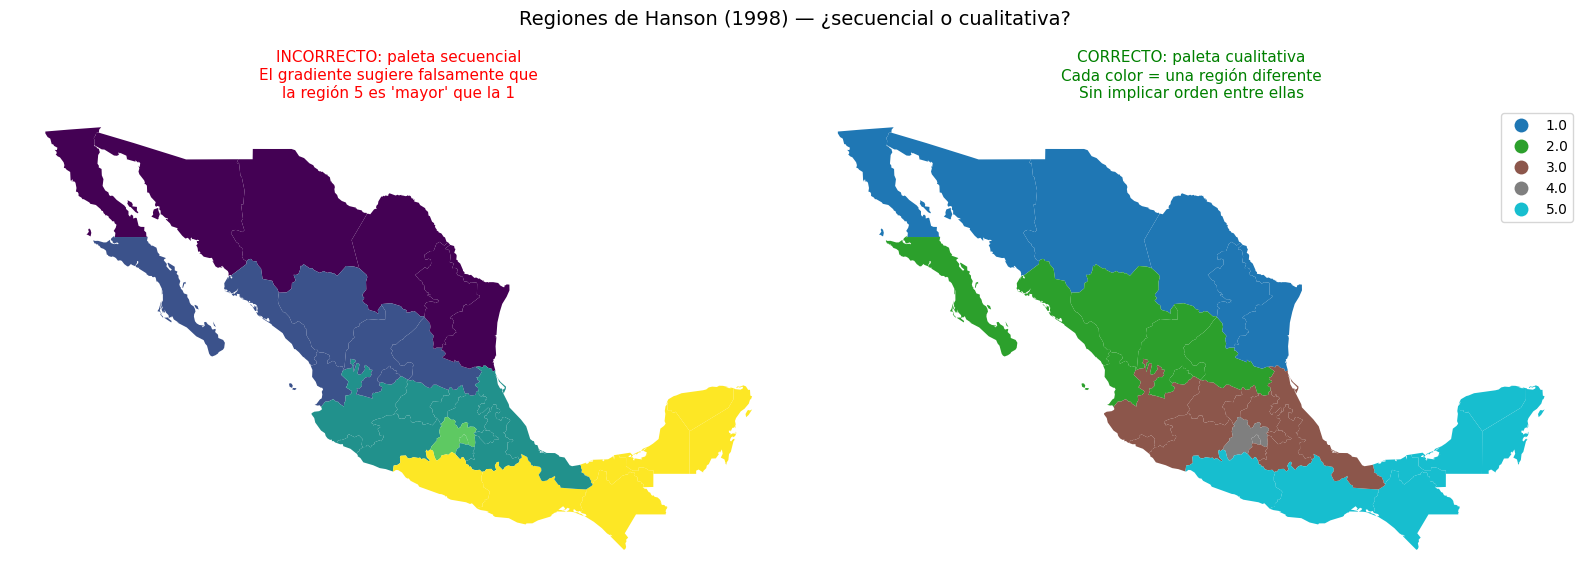

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# INCORRECTO: paleta secuencial (gradiente) para variable categórica
mx.plot("HANSON98", ax=axes[0])
axes[0].set_axis_off()
axes[0].set_title(
    "INCORRECTO: paleta secuencial\n"
    "El gradiente sugiere falsamente que\n"
    "la región 5 es 'mayor' que la 1",
    fontsize=11, color="red"
)

# CORRECTO: paleta cualitativa
# categorical=True le dice a geopandas que los valores son categorías,
# no números continuos. Esto activa automáticamente una paleta sin gradiente.
mx.plot("HANSON98", categorical=True, legend=True, ax=axes[1])
axes[1].set_axis_off()
axes[1].set_title(
    "CORRECTO: paleta cualitativa\n"
    "Cada color = una región diferente\n"
    "Sin implicar orden entre ellas",
    fontsize=11, color="green"
)

plt.suptitle("Regiones de Hanson (1998) — ¿secuencial o cualitativa?", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## PARTE 7: Clasificaciones personalizadas y agrupadas

### 7.1 Clasificación definida por el usuario (*User Defined*)

A veces los cortes no deben venir de un algoritmo sino de **conocimiento del dominio** o **criterios de política pública**.

**Ejemplo:** Como analistas de política pública, clasificamos los estados según su PIB per cápita en 2000:
- **Pobreza crítica:** menos de \$10,000
- **Ingresos bajos:** \$10,000 a \$12,500
- **Ingresos medios:** \$12,500 a \$15,000
- **Ingresos altos:** más de \$15,000

In [40]:
# mapclassify.UserDefined: tú defines los puntos de corte.
# El segundo argumento es una lista con los LÍMITES SUPERIORES de cada clase
# (excepto la última, que va hasta el máximo automáticamente).

classi = mapclassify.UserDefined(
    mx["PCGDP2000"],       # Variable a clasificar
    [10000, 12500, 15000]  # Los 3 puntos de corte -> generan 4 clases
)
classi

UserDefined

      Interval         Count
----------------------------
[ 8684.00, 10000.00] |     2
(10000.00, 12500.00] |     7
(12500.00, 15000.00] |     1
(15000.00, 54349.00] |    22

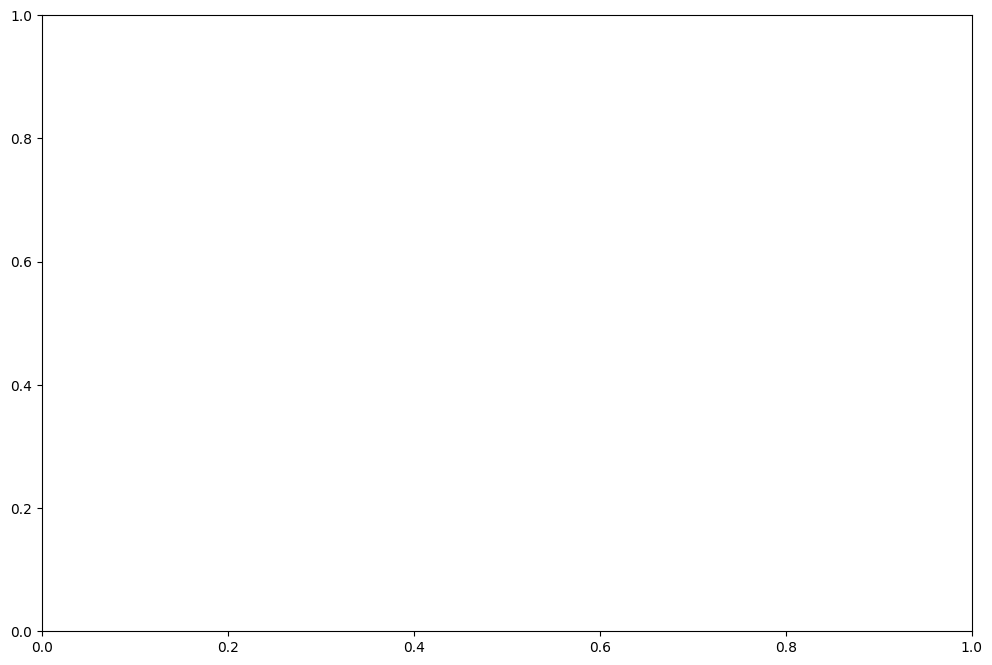

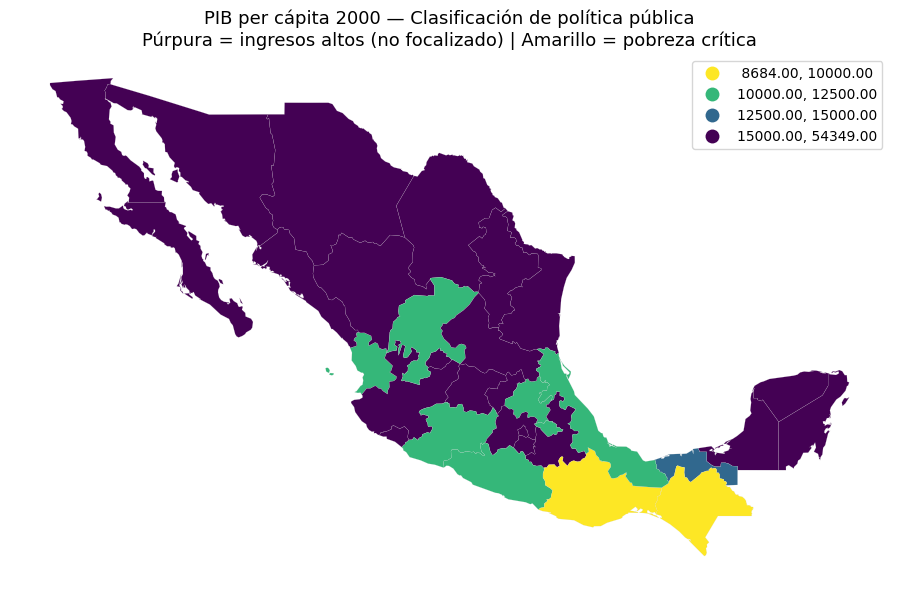

In [41]:
# Mapa con clasificación personalizada
fig, ax = plt.subplots(1, figsize=(12, 8))
classi.plot(
    mx,
    legend=True,
    legend_kwds={"loc": "upper right"},
    axis_on=False,
    cmap="viridis_r",    # viridis invertido: púrpura=alto, amarillo=bajo
)
plt.title(
    "PIB per cápita 2000 — Clasificación de política pública\n"
    "Púrpura = ingresos altos (no focalizado) | Amarillo = pobreza crítica",
    fontsize=13
)
plt.tight_layout()
plt.show()

### 7.2 Clasificación agrupada (*Pooled*)

**El problema:** Queremos comparar mapas del PIB per cápita en **diferentes décadas**. Si clasificamos cada mapa por separado, cada uno tendrá sus propios puntos de corte. El color "verde oscuro" en 1940 puede significar \$8,000 pero en 2000 puede significar \$40,000. **No podemos comparar colores entre mapas.**

**La solución:** Crear una **clasificación única** que tome **todos los valores de todos los años** (32 estados × 4 años = 128 valores) y calcule los puntos de corte sobre ese conjunto completo. Así, el mismo color siempre significa el mismo rango de PIB, sin importar el año.

In [42]:
# Las 4 columnas temporales que queremos comparar
years = ["PCGDP1940", "PCGDP1960", "PCGDP1980", "PCGDP2000"]

# mapclassify.Pooled:
#   - mx[years].values -> extrae los valores como un array NumPy de forma (32, 4)
#     Es decir, 128 valores en total. Pooled los trata todos como una sola distribución.
#   - classifier="Quantiles" -> usa cuantiles para clasificar
#   - k=5 -> 5 clases

pooled = mapclassify.Pooled(
    mx[years].values,
    classifier="Quantiles",
    k=5
)

print("Puntos de corte GLOBALES (compartidos por los 4 mapas):")
print(pooled.global_classifier.bins)
print()
print("Estos mismos cortes se aplican a 1940, 1960, 1980 Y 2000.")
print("Así, 'verde oscuro' siempre significa el mismo rango de PIB.")

Puntos de corte GLOBALES (compartidos por los 4 mapas):
[ 6399.   9664.2 13941.6 21509.2 54349. ]

Estos mismos cortes se aplican a 1940, 1960, 1980 Y 2000.
Así, 'verde oscuro' siempre significa el mismo rango de PIB.


In [ ]:
# Panel de 4 mapas con clasificación pooled
f, axs = plt.subplots(2, 2, figsize=(14, 12))
axs = axs.flatten()  # Convierte la matriz 2×2 en lista plana para iterar

titulos = {
    "PCGDP1940": "PIB per cápita 1940",
    "PCGDP1960": "PIB per cápita 1960",
    "PCGDP1980": "PIB per cápita 1980",
    "PCGDP2000": "PIB per cápita 2000",
}

for i, y in enumerate(years):
    mx.plot(
        y,
        scheme="UserDefined",
        classification_kwds={"bins": pooled.global_classifier.bins},
        legend=True,
        legend_kwds={"fontsize": 7},
        ax=axs[i],
    )
    axs[i].set_axis_off()
    axs[i].set_title(titulos[y], fontsize=12)

plt.suptitle(
    "Evolución del PIB per cápita en México (1940-2000)\n"
    "Clasificación pooled: mismos cortes en los 4 mapas → colores comparables",
    fontsize=14
)
plt.tight_layout()
plt.show()

**¿Qué patrones ves?** Ahora sí puedes comparar directamente: si un estado pasa de amarillo claro en 1940 a verde oscuro en 2000, significa que su PIB per cápita creció significativamente respecto al conjunto completo de datos. Observa si la desigualdad entre norte y sur cambia con las décadas.

---

## PARTE 8: Guía de decisión

### ¿Qué clasificador elegir?

| Si tu distribución es... | Y tu objetivo es... | Usa... |
|:---|:---|:---|
| Cualquiera | Simplicidad e interpretabilidad | **Intervalos iguales** |
| Cualquiera | Clases equilibradas en tamaño | **Cuantiles** |
| Simétrica / normal | Centrar en la media | **Media-Desv. Est.** |
| Con grupos separados | Detectar brechas naturales | **Cortes máximos** |
| Cualquiera | Identificar outliers | **Box Plot** |
| Cola pesada (ley de potencia) | Capturar la asimetría | **Head-Tail Breaks** |
| Cualquiera | La mejor clasificación estadística | **Fisher-Jenks** |
| — | Cortes con significado de política o dominio | **UserDefined** |

### ¿Qué paleta de color elegir?

| Tipo de variable | Paleta | Ejemplos | ¿Por qué? |
|:---|:---|:---|:---|
| Continua con orden (PIB, población) | **Secuencial** | `Blues`, `YlGn`, `viridis` | Gradiente implica "más/menos" |
| Cambio con centro neutro (diferencias) | **Divergente** | `RdYlGn`, `RdBu` | Dos extremos y un centro |
| Categorías sin orden (regiones, tipos) | **Cualitativa** | `Set1`, `tab10` | Colores distintos sin gradiente |

---

## PARTE 9: Ejercicios

**Ejercicio 1 — Exploración:**  
Toma `PCGDP2000`: haz histograma, `.describe()`, y describe la forma de la distribución. ¿Más o menos asimétrica que 1940?

**Ejercicio 2 — Clasificadores:**  
Aplica EqualInterval, Quantiles y FisherJenks a `PCGDP2000` con $k=5$. Compara ADCM. ¿Cambia el ranking de clasificadores?

**Ejercicio 3 — Empates:**  
Con $y = [2,2,2,2,2,2,4,7,8,9,20,21]$, aplica `Quantiles` con $k=4$. ¿Cuántas clases obtienes? Explica por qué.

**Ejercicio 4 — Mapas lado a lado:**  
Crea una figura con 3 mapas de `PCGDP1940`, cada uno con un clasificador diferente. Misma paleta. ¿Cuál comunica mejor la desigualdad?

**Ejercicio 5 — Paleta divergente:**  
Calcula la diferencia absoluta de PIB per cápita (2000 - 1940) para cada estado. Haz un mapa con paleta divergente.

**Ejercicio 6 — Reflexión:**  
Fisher-Jenks es "óptimo" según ADCM. Entonces ¿por qué no lo usamos siempre? Da al menos dos razones.

---

## Referencias

- Rey, S. J., Arribas-Bel, D. y Wolf, L. J. (2020). *Geographic Data Science with Python*. Cap. 5.
- Rey, S. J. y Sastré-Gutiérrez, M. L. (2010). Interregional inequality dynamics in Mexico. *Spatial Economic Analysis*, 5(3), 277-298.
- Jenks, G. F. y Caspall, F. C. (1971). Error on choroplethic maps. *Annals of the AAG*, 61(2), 217–244.
- Jiang, B. (2013). Head/tail breaks: A new classification scheme. *The Professional Geographer*, 65(3), 482–494.
- Duque, J.C., Anselin, L. y Rey, S. J. (2011). The max-p-regions problem. *Journal of Regional Science*, 52(3), 397–419.
- Brewer, C. A. et al. (1997). Mapping mortality: evaluating color schemes for choropleth maps. *Annals of the AAG*, 87(3), 411–438.
- Freedman, D. y Diaconis, P. (1981). On the histogram as a density estimator. *Zeitschrift für Wahrscheinlichkeitstheorie*, 57(4), 453–476.